PHASE - 1
(Sample Size and Sanity Check)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Using 'statsmodels' for advanced statistics in Python.
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import chi2_contingency

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Setting order for our weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
np.random.seed(42) # Ensures our random simulations are exactly the same every time

print("Libraries imported successfully!")


Libraries imported successfully!


PHASE - 2 (Data Load)

In [5]:
df = pd.read_csv('marketing_AB.csv')

print(f"Dataset loaded! Total rows: {len(df)}")

Dataset loaded! Total rows: 588101


PHASE - 3 (caluclating Reaquired Sample size)

In [6]:
# 1. What is the normal conversion rate without ads? (Our baseline)
cr_psa = df[df['test group'] == 'psa']['converted'].mean()

# 2. What is our target? We want at least a 0.5% boost (0.005)
cr_mde = cr_psa + 0.005

# 3. Standard Statistical rules (Alpha = 5% error margin, Power = 80% confidence)
alpha = 0.05
power = 0.8

# 4. Calculate the 'Effect Size' (the mathematical distance between baseline and target)
effect_size = proportion_effectsize(cr_mde, cr_psa)

# 5. Run the Power Analysis
analysis = NormalIndPower()
sample_size = analysis.solve_power(effect_size=effect_size,
                                   power=power,
                                   alpha=alpha,
                                   alternative='larger',
                                   ratio=1)

print(f"To trust this test, we needed at least {int(sample_size)} users per group.")

To trust this test, we needed at least 9825 users per group.


In [7]:
# Drop the 'Unnamed: 0' column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Rename columns to remove spaces
df = df.rename(columns={
    'user id': 'user_id',
    'test group': 'test_group',
    'total ads': 'total_ads',
    'most ads day': 'most_ads_day',
    'most ads hour': 'most_ads_hour'
})

# Changing data types to save memory and user friendly
df['test_group'] = df['test_group'].astype('category')
# Changes True/False to 1/0
df["converted"] = df["converted"].astype(int)
df['most_ads_day'] = df['most_ads_day'].astype("category")
df['most_ads_hour'] = df['most_ads_hour'].astype("category")

# Drop duplicate users
df = df.drop_duplicates(subset='user_id')

print("Data cleaned and ready for analysis!")


Data cleaned and ready for analysis!


In [8]:
# 6.Did the system show ads fairly across days and hours?
# We use a crosstab (a simple grid) and a chi-square test to check the traffic split.

# Check Days
contingency_day = pd.crosstab(df['test_group'], df['most_ads_day'])
chi2_day, p_day, _, _ = chi2_contingency(contingency_day)

# Check Hours
contingency_hour = pd.crosstab(df['test_group'], df['most_ads_hour'])
chi2_hour, p_hour, _, _ = chi2_contingency(contingency_hour)

print(f"Day-of-week traffic distribution p-value: {p_day}")
print(f"Hour-of-day traffic distribution p-value: {p_hour}")

Day-of-week traffic distribution p-value: 4.849067664297987e-48
Hour-of-day traffic distribution p-value: 1.094573971081402e-28


PHASE - 6 (The Z-Test)

In [9]:
# 7.Did the ads work ??
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# 1. Count how many people converted in each group
conv = df.groupby('test_group')['converted'].sum()

# 2. Count the total number of people in each group
n = df.groupby('test_group')['converted'].count()

# 3. Run the Z-Test (We use alternative='larger' because we expect Ads to be better than PSA)
z_stat, p_value = proportions_ztest(conv, n, alternative='larger')

# 4. Calculate the Confidence Interval
ci_low, ci_high = confint_proportions_2indep(conv['ad'], n['ad'], conv['psa'], n['psa'])

# 5. Calculate the actual Lift (How much better did the ads do in percentages?)
lift_pp = (conv['ad']/n['ad'] - conv['psa']/n['psa']) * 100

print("--- STANDARD MATH RESULTS ---")
print(f"P-Value: {p_value}") # If this is < 0.05, the ads worked!
print(f"Absolute Lift: {lift_pp:.3f}%")
print(f"We are 95% confident the true lift is between {ci_low*100:.3f}% and {ci_high*100:.3f}%")


--- STANDARD MATH RESULTS ---
P-Value: 8.526403580779863e-14
Absolute Lift: 0.769%
We are 95% confident the true lift is between 0.587% and 0.936%


PHASE - 7 (Bootstrapping (The Robustness Check))

In [10]:
# Get the raw 1s and 0s (Converted / Not Converted) for both groups
ad_data = df[df['test_group'] == 'ad']['converted'].values
psa_data = df[df['test_group'] == 'psa']['converted'].values

n_boot = 5000 # Number of alternate realities we want to simulate
boot_diffs = []

print(f"Starting {n_boot} bootstrap simulations...")

for i in range(n_boot):
    # Randomly pick users from our groups (with replacement)
    ad_sample = np.random.choice(ad_data, size=len(ad_data), replace=True)
    psa_sample = np.random.choice(psa_data, size=len(psa_data), replace=True)

    # Calculate the difference in conversion rates for this simulation
    diff = ad_sample.mean() - psa_sample.mean()
    boot_diffs.append(diff)

# Convert our 5,000 results into a numpy array so we can do math on it
boot_diffs = np.array(boot_diffs)

# Find the 2.5% and 97.5% marks to create a 95% Confidence Interval from our simulations
boot_ci_low, boot_ci_high = np.percentile(boot_diffs, [2.5, 97.5])

# How many times did the PSA group beat the Ad group? (Calculate P-value)
boot_p_value = np.mean(boot_diffs <= 0)

print("\n--- BOOTSTRAP SIMULATION RESULTS ---")
print(f"Simulated P-Value: {boot_p_value:.3f}")
print(f"Simulated 95% Confidence Interval: {boot_ci_low*100:.3f}% to {boot_ci_high*100:.3f}%")
print("\nConclusion: the Simulated P-Value is 0.000, it means the Ads beat the PSAs in almost every single one of the 5,000 cases!")

Starting 5000 bootstrap simulations...

--- BOOTSTRAP SIMULATION RESULTS ---
Simulated P-Value: 0.000
Simulated 95% Confidence Interval: 0.591% to 0.941%

Conclusion: the Simulated P-Value is 0.000, it means the Ads beat the PSAs in almost every single one of the 5,000 cases!


PHASE - 8 (Day of the week Analysis)

--- DAILY CONVERSION RATES ---
test_group          ad       psa
most_ads_day                    
Monday        3.324120  2.255854
Tuesday       3.044038  1.444788
Wednesday     2.535586  1.575931
Thursday      2.163714  2.023047
Friday        2.246495  1.630292
Saturday      2.130657  1.399580
Sunday        2.461983  2.059497


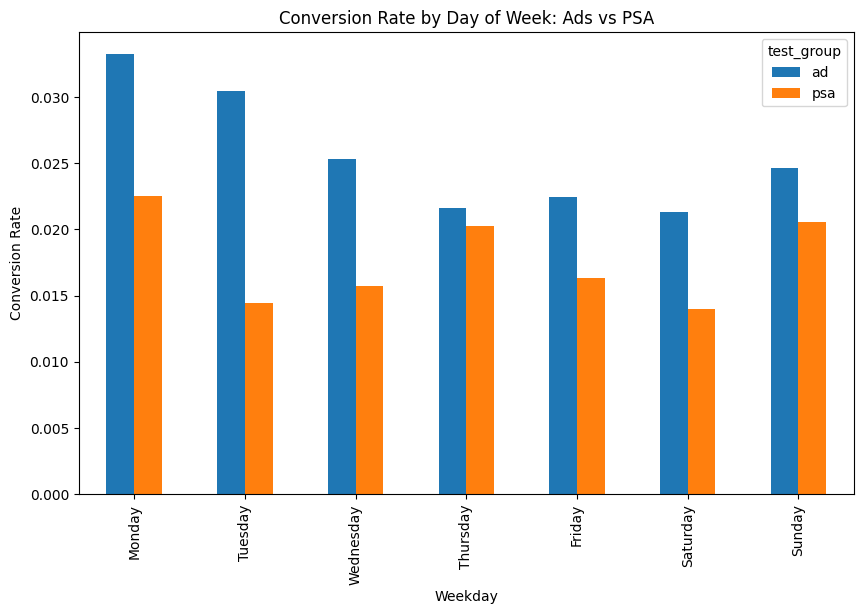


--- ANOVA RESULTS ---
                                     df        sum_sq   mean_sq          F  \
C(test_group)                       1.0      1.336325  1.336325  54.361228   
C(most_ads_day)                     6.0     10.068857  1.678143  68.266244   
C(test_group):C(most_ads_day)       6.0      0.430494  0.071749   2.918723   
Residual                       588087.0  14456.543895  0.024582        NaN   

                                     PR(>F)  
C(test_group)                  1.670394e-13  
C(most_ads_day)                2.589796e-85  
C(test_group):C(most_ads_day)  7.574369e-03  
Residual                                NaN  

 Results: If the p-value for the interaction is < 0.05, the ads perform significantly differently depending on the day of the week.


In [11]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

print("--- DAILY CONVERSION RATES ---")
# 1. Calculate the conversion rate for each day and group
cr_day = df.groupby(['most_ads_day', 'test_group'])['converted'].mean().unstack()

# 2. Reorder the days so they appear logically in our chart
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cr_day = cr_day.reindex(weekday_order)

# Display the table
print(cr_day * 100) # Multiply by 100 to show percentages

# 3. Plot a Bar Chart
cr_day.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Conversion Rate by Day of Week: Ads vs PSA')
plt.ylabel('Conversion Rate')
plt.xlabel('Weekday')
plt.show()

# 4. Run the ANOVA Test
# The formula 'modal_anova' tells the model to check, if the Test Group and the Day of the Week INTERACT with each other to affect conversions.
model_anova = smf.ols('converted ~ C(test_group) * C(most_ads_day)', data=df).fit()
anova_results = anova_lm(model_anova)

print("\n--- ANOVA RESULTS ---")
# We look at the PR(>F) column. If it's less than 0.05, the day of the week matters!
print(anova_results)
print("\n Results: If the p-value for the interaction is < 0.05, the ads perform significantly differently depending on the day of the week.")

PHASE - 9 (Hourly Analysis)


--- HOURLY LOGISTIC REGRESSION ---
Top 5 Best Hours to Run Ads:
    Hour of Day  Predicted Conversion Probability
16           16                          0.030893
20           20                          0.030274
15           15                          0.029845
21           21                          0.029175
14           14                          0.028575

Worst 5 Hours to Run Ads:
   Hour of Day  Predicted Conversion Probability
7            7                          0.018482
4            4                          0.015850
1            1                          0.013434
3            3                          0.010425
2            2                          0.007570


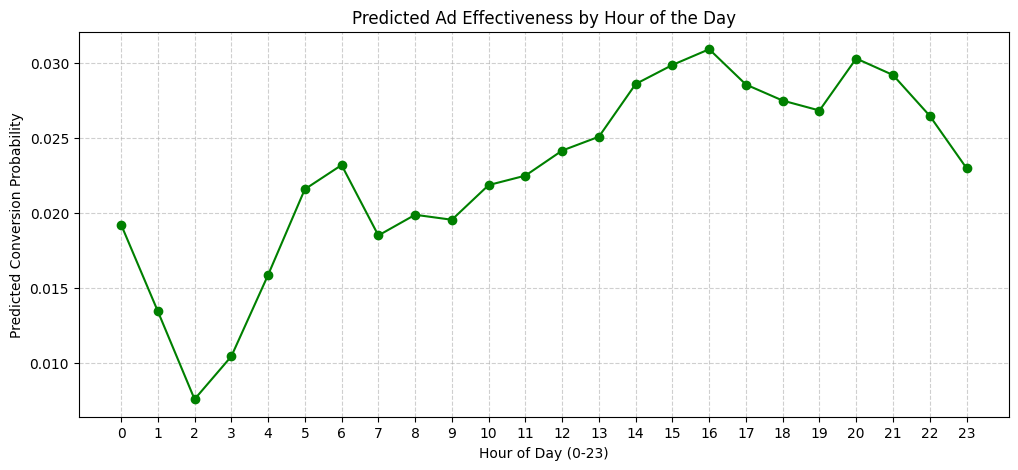

In [12]:
print("\n--- HOURLY LOGISTIC REGRESSION ---")
# We only care about the Ad group for this, because we want to know when to show ads.
ad_df = df[df['test_group'] == 'ad'].copy()

# 1. Train the Logistic Regression Model
# We are predicting 'converted' based on the category 'most_ads_hour'
logit_model = smf.logit('converted ~ C(most_ads_hour)', data=ad_df).fit(disp=False)

# 2. Create a dummy dataframe representing all 24 hours in a day
hours_df = pd.DataFrame({'most_ads_hour': range(24)})

# 3. Use the trained model to PREDICT the conversion probability for each hour
predictions = logit_model.predict(hours_df)

# 4. Combine the hours and predictions into one neat table
hourly_effect = pd.DataFrame({
    'Hour of Day': range(24),
    'Predicted Conversion Probability': predictions
})

# 5. Sort to find the absolute best hours to show ads!
best_hours = hourly_effect.sort_values(by='Predicted Conversion Probability', ascending=False)

print("Top 5 Best Hours to Run Ads:")
print(best_hours.head())

print("\nWorst 5 Hours to Run Ads:")
print(best_hours.tail())

# 6. Visualize the Hourly Trend
plt.figure(figsize=(12, 5))
plt.plot(hourly_effect['Hour of Day'], hourly_effect['Predicted Conversion Probability'], marker='o', color='green')
plt.title('Predicted Ad Effectiveness by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Predicted Conversion Probability')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()